# Evaluacija — poređenje sa baseline metodom i BSDS500

Cilj ove sveske je da objektivnije proceni koliko spektralno klasterovanje zaista doprinosi kvalitetu segmentacije, kroz dva pristupa:

1. **Poređenje sa baseline metodom** — K-means primenjen direktno na karakteristike superpiksela (boja + pozicija), bez konstrukcije grafa i Laplasijana. Ovo pokazuje da li graf-bazirani pristup zaista donosi prednost u odnosu na jednostavnije klasterovanje.
2. **Kvantitativna evaluacija na BSDS500** — poređenje segmentacije sa svim dostupnim ground-truth anotacijama, korišćenjem Adjusted Rand Index (ARI) metrike.

Tok sveske:
1. Baseline metoda (K-means bez grafovske strukture)
2. Vizuelno poređenje: spektralno klasterovanje vs baseline
3. BSDS500 — priprema podataka
4. Kvantitativna evaluacija (ARI), uz variranje k
5. Konačni zaključak

In [7]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.segmentation import slic

from image_utils import (
    compute_superpixel_features,
    build_image_similarity_matrix
)

from spectral import spectral_clustering_from_similarity
from segmentation import baseline_kmeans_segmentation
from evaluation import evaluate_segmentation, evaluate_bsds_images
from visualization import compare_segmentations, plot_segmentation_results, plot_ari_comparison

## 1. Baseline metoda — K-means bez grafovske strukture

Baseline pristup koristi iste karakteristike superpiksela (prosečna boja i pozicija) kao i spektralno klasterovanje, ali ih klasteruje direktno, standardnim K-means algoritmom — bez konstrukcije grafa sličnosti, Laplasijana, ili sopstvene-dekompozicije. Poređenje ova dva pristupa pokazuje da li graf-bazirana reprezentacija zaista doprinosi kvalitetu segmentacije, ili je razlika zanemarljiva.

## 2. Vizuelno poređenje: spektralno klasterovanje vs baseline

Upoređujemo oba pristupa na istoj slici (cvet na uniformnoj pozadini), korišćenjem istog parametra k.

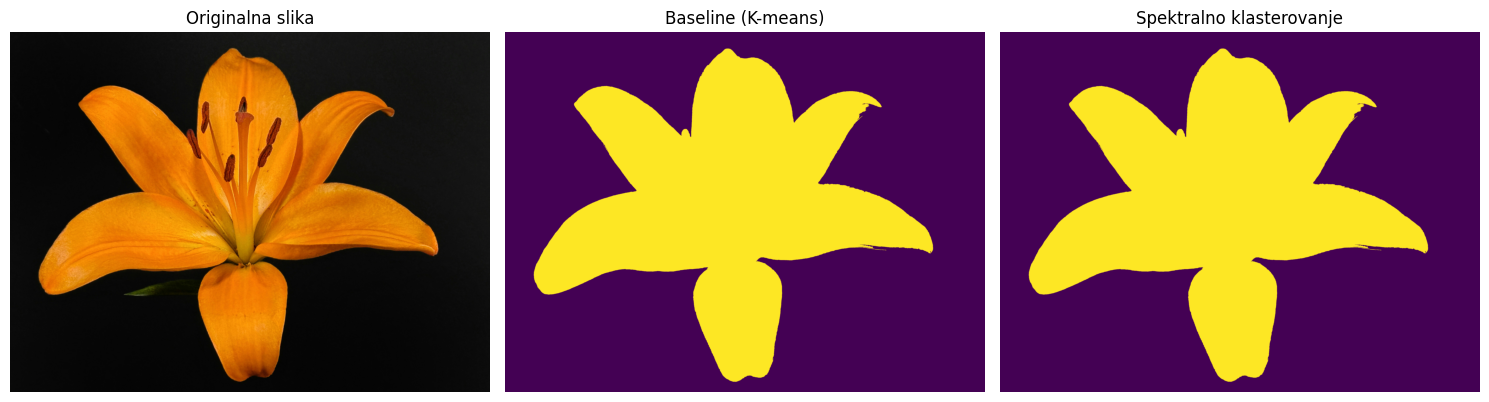

In [8]:
compare_segmentations(
    '../data/sample_images/yellow_lilly.jpg',
    k=2
)

**Zapažanje:** Na ovoj slici, baseline metoda daje rezultat praktično identičan spektralnom 
klasterovanju — oba pristupa čisto i tačno izdvajaju cvet od pozadine. Ovo je očekivano s obzirom 
na prirodu slike: uniformna pozadina i jasno kontrastan objekat čine da je granica između klastera 
jednostavna (skoro linearno razdvojiva), pa dodatna 
grafovska struktura ne donosi značajnu prednost.

### 2.1 Poređenje na slici gde spektralno klasterovanje ima teškoće

Ponavljamo poređenje na slici sa poljima cveća, gde je spektralno klasterovanje ranije pokazalo tendenciju ka deljenju po poziciji umesto po sadržaju.

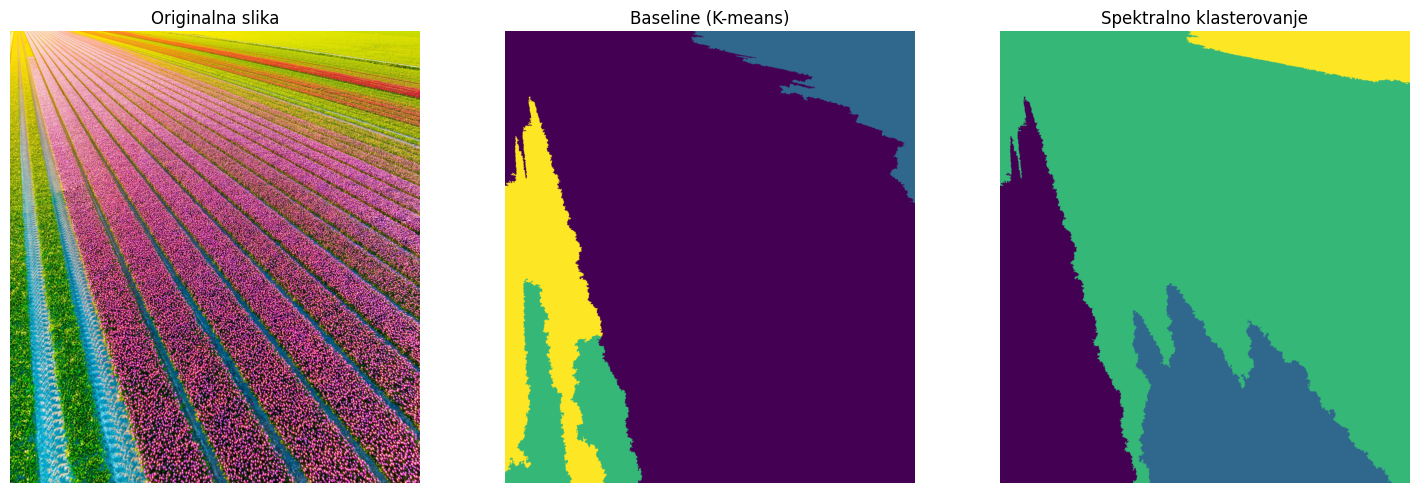

In [9]:
compare_segmentations(
    '../data/sample_images/fields.jfif',
    k=4
)

**Zapažanje:** Ni K-means ni spektralno klasterovanje ne uspevaju da izdvoje pojedinačne redove cveća, već formiraju veće regione na osnovu sličnosti u boji i položaju. To ukazuje da ograničenje nije samo u izboru algoritma klasterovanja, već i u korišćenim karakteristikama (boja + pozicija), koje ne opisuju dovoljno dobro periodičnu i teksturalnu strukturu ove slike.

## 3. BSDS500 — priprema podataka

[Berkeley Segmentation Dataset (BSDS500)](https://www2.eecs.berkeley.edu/Research/Projects/CS/vision/grouping/resources.html) sadrži slike sa ručno beleženim ground-truth segmentacijama (više anotatora po slici), što omogućava kvantitativnu evaluaciju.

Tri slike i odgovarajući ground-truth `.mat` fajlovi preuzeti su iz BSDS500 dataseta i sačuvani u `data/bsds500/images/` i `data/bsds500/ground_truth/`.

## 4. Kvantitativna evaluacija (ARI)

Za poređenje dobijene segmentacije sa ground-truth segmentacijama koristimo **Adjusted Rand Index (ARI)**. Ova metrika meri stepen slaganja između dve podele skupa na klastere, nezavisno od konkretnih oznaka dodeljenih klasterima. Vrednost 1 označava savršeno poklapanje, dok vrednost bliska 0 ukazuje na slaganje približno nivou koji bi se mogao očekivati slučajnim pogađanjem.

BSDS500 sadrži više nezavisnih ljudskih segmentacija za istu sliku. Umesto izbora samo jednog anotatora, ARI se računa posebno prema **svakom dostupnom anotatoru**. Za svaku sliku i metod zadržava se puna lista ARI vrednosti, a u tabeli se rezultat sažima pomoću **srednje vrednosti i standardne devijacije**. Srednja vrednost opisuje prosečno slaganje sa ljudskim segmentacijama, dok standardna devijacija pokazuje koliko se ocena menja između različitih anotatora.

Testiramo sa tri vrednosti k (2, 3, 4), pošto ground-truth segmentacije za različite slike sadrže različit broj regiona — fiksna vrednost k ne mora odgovarati svakoj slici podjednako dobro.

In [10]:
bsds_image_names = ['107072', '108004', '147080']
k_values = [2, 3, 4]

all_results, ari_table = evaluate_bsds_images(
    bsds_image_names,
    k_values,
    position_ratio=0.1
)

ari_table.style.format({
    'ARI - Spektralno (mean)': '{:.3f}',
    'ARI - Spektralno (std)': '{:.3f}',
    'ARI - Baseline (mean)': '{:.3f}',
    'ARI - Baseline (std)': '{:.3f}'
})

,Slika,k,Broj anotatora,ARI - Spektralno (mean),ARI - Spektralno (std),ARI - Baseline (mean),ARI - Baseline (std)
0,107072,2,7,0.245,0.139,0.242,0.139
1,108004,2,5,0.007,0.002,-0.009,0.010
2,147080,2,5,0.205,0.065,0.200,0.070
3,107072,3,7,0.279,0.136,0.356,0.143
4,108004,3,5,0.034,0.013,-0.070,0.015
5,147080,3,5,0.307,0.084,0.316,0.096
6,107072,4,7,0.168,0.107,0.325,0.135
7,108004,4,5,-0.024,0.012,0.002,0.011
8,147080,4,5,0.303,0.088,0.325,0.094


**Zapažanje:** Kada se uzmu u obzir svi anotatori, slika 107072 ima 7, a slike 108004 i 147080 po 5 ground-truth segmentacija. Za k=3, spektralno klasterovanje ima prosečni ARI 0.279 ± 0.136 na slici 107072, 0.034 ± 0.013 na slici 108004 i 0.307 ± 0.084 na slici 147080. Baseline za iste slike daje 0.356 ± 0.143, -0.070 ± 0.015 i 0.316 ± 0.096.

Rezultati pokazuju da nijedna metoda nije dosledno bolja u svim slučajevima. Spektralno klasterovanje jasno nadmašuje baseline na slici 108004 za k=2 i k=3, dok baseline ima prednost na slici 107072 za k=3 i k=4 i blagu prednost na slici 147080 za k=3 i k=4. Standardne devijacije su posebno veće za slike 107072 i 147080, što pokazuje da se stepen slaganja algoritamske segmentacije razlikuje između ljudskih anotacija i potvrđuje da evaluacija prema samo jednom anotatoru može dati nepotpunu sliku.

### 4.1 Vizuelni prikaz rezultata (k = 3)

Prikazujemo grid rezultata za k=3, koje je dalo najbolji generalni rezultat u tabeli iznad.

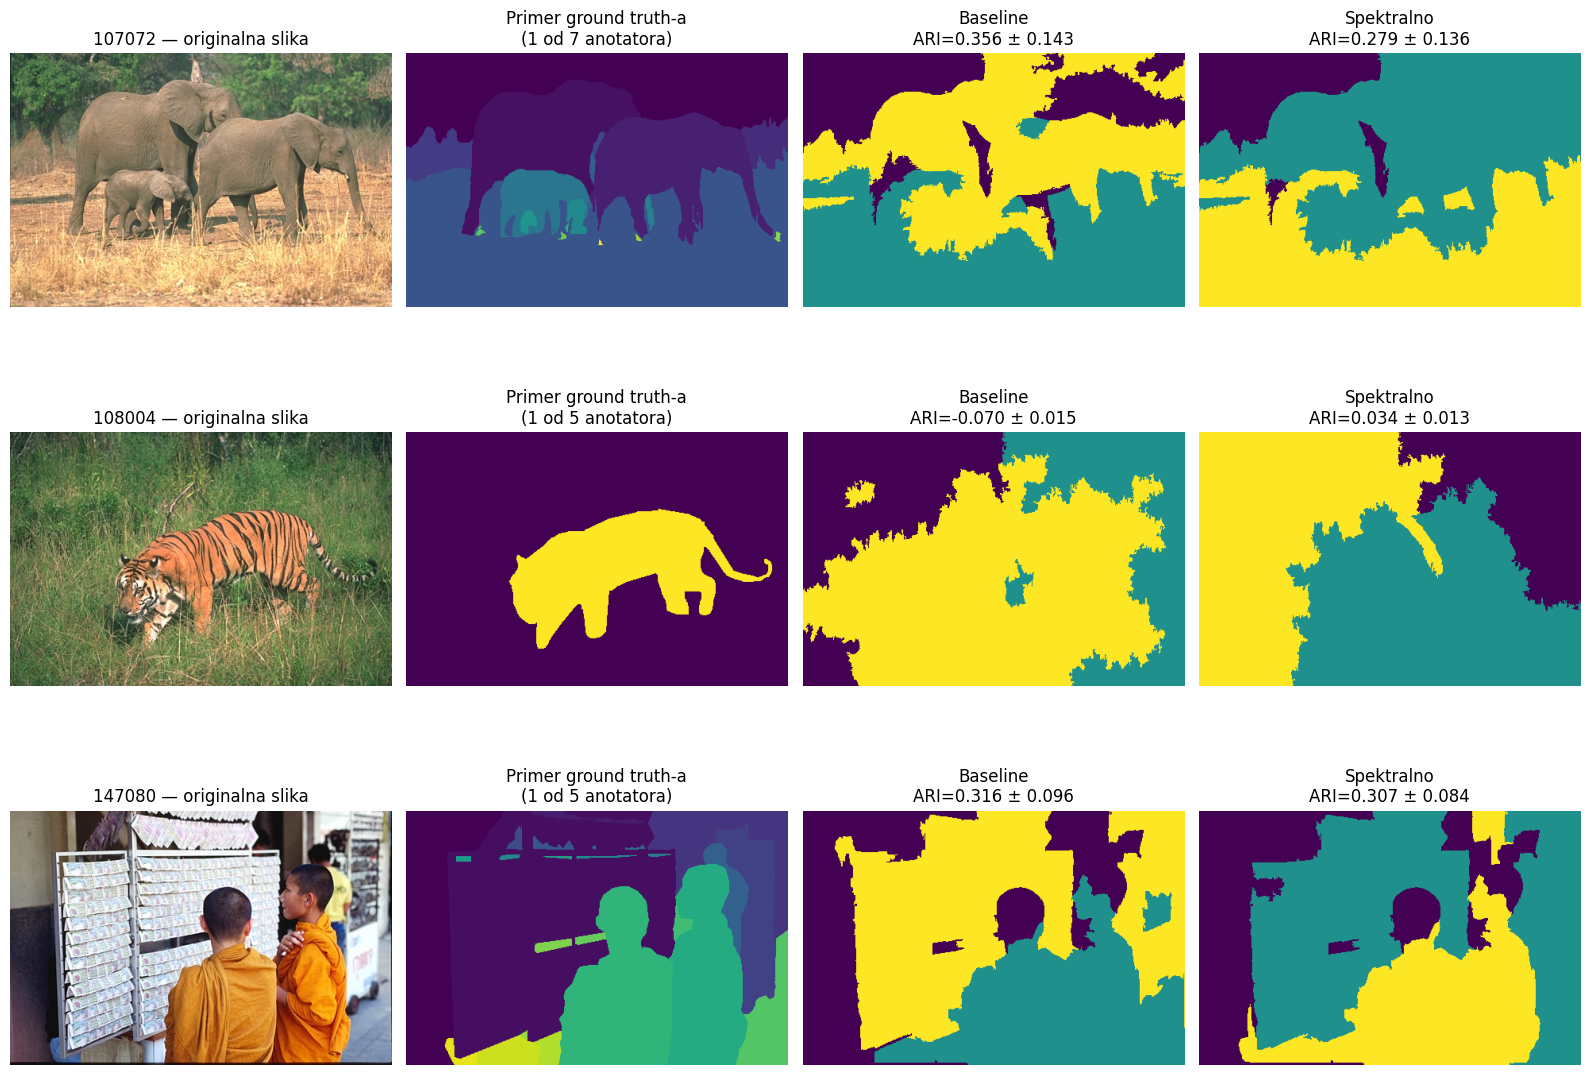

In [11]:
plot_segmentation_results(all_results, k = 3)

**Zapažanje:** Vizuelnim pregledom rezultata za $k=3$ uočava se da obe metode hvataju grubu strukturu pojedinih objekata, ali granice često ne prate precizno ljudske segmentacije. Prikazan je samo jedan ground truth kao vizuelni primer, dok ARI vrednosti u naslovima predstavljaju srednju vrednost ± standardnu devijaciju preko svih anotatora. Na slici 108004 spektralno klasterovanje je u proseku bliže ljudskim anotacijama od baseline-a, iako je apsolutni ARI i dalje nizak. Na slikama 107072 i 147080 baseline postiže nešto veći prosečni ARI za $k=3$. Rezultati pokazuju da grafovska reprezentacija može pomoći u pojedinim slučajevima, ali ne donosi univerzalnu prednost na ovom malom uzorku realnih fotografija.

### Grafičko poređenje ARI po metodi (k = 3)

Stubići prikazuju **prosečni ARI preko svih anotatora**, a error bar predstavlja standardnu devijaciju između anotatora za svaku sliku.

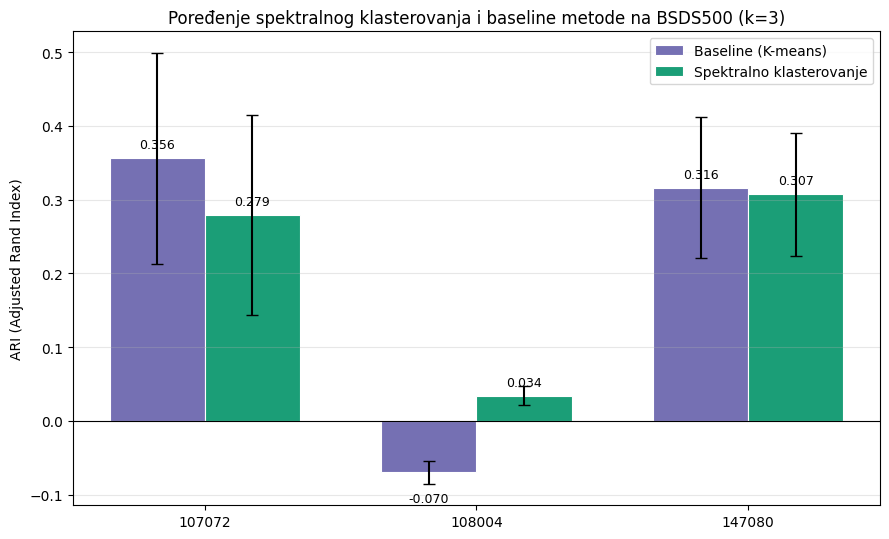

In [12]:
plot_ari_comparison = plot_ari_comparison
plot_ari_comparison(all_results, k=3)

## Konačni zaključak

Poređenje sa baseline metodom (K-means bez grafovske strukture), kako vizuelno tako i kroz 
BSDS500 evaluaciju, pokazuje da spektralno klasterovanje ne daje dosledno bolje rezultate od 
jednostavnijeg pristupa na realnim fotografijama. U pojedinim slučajevima spektralno klasterovanje 
postiže bolji ARI, dok u drugim bolje rezultate daje baseline, pa se ne može izdvojiti metoda koja 
je univerzalno bolja na posmatranom uzorku. Pokazalo se i da je `k` jedan od najosetljivijih 
hiperparametara, pri čemu odgovarajući broj klastera zavisi od strukture konkretne slike.

Ovakav rezultat je u kontrastu sa sintetičkim `make_moons` podacima, na kojima je prednost 
spektralnog klasterovanja u prepoznavanju nekonveksnih struktura jasno pokazana. To ukazuje da se 
teorijske prednosti metode ne prenose nužno na svaki tip podataka. Kod realnih fotografija, 
korišćene karakteristike zasnovane na boji i poziciji ne moraju dovoljno dobro da opišu složene 
objekte, teksture i granice regiona, pa grafovska reprezentacija i složenija metoda klasterovanja 
ne garantuju bolju segmentaciju.